In [1]:
### EEG 100ms ###

In [2]:
def qwen_layer_order(layer_name):
    """Sort key respecting Qwen's vision→language hierarchy."""
    short = layer_name.split("/")[-1]
    if short.startswith("visual-blocks"):
        block_n = int(re.search(r"\d+", short).group())
        return (0, block_n)  # vision comes first
    elif short.startswith("language_model-layers"):
        layer_n = int(re.search(r"\d+", short).group())
        return (1, layer_n)  # language comes second
    else:
        return (2, short)    # fallback

def resnet_layer_order(layer_name):
    """Sort key for ResNet: layer1 < layer2 < layer3 < layer4, then by block."""
    short = layer_name.split("/")[-1]
    # e.g. "layer3-15" → ("layer", 3, 15)
    m = re.match(r"layer(\d+)-(\d+)", short)
    if m:
        return (int(m.group(1)), int(m.group(2)))
    return (99, short)

def order_layers(df, model_name):
    if "ResNet" in model_name:
        key_fn = resnet_layer_order
    elif "Qwen" in model_name:
        key_fn = qwen_layer_order
    else:
        key_fn = natkey
    sub = df[df["model"] == model_name].copy()
    sub["_order"] = sub["layer"].map(key_fn)
    return sub.sort_values("_order").drop(columns=["_order"]).reset_index(drop=True)

In [3]:
import pandas as pd

df_results = pd.read_csv("cuda_eeg_100ms_full.csv")
df_results.head()

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka
0,EEG2,Model A (ResNet),features/layer1-0,occipital_parietal,1000000.000000,0.515615,0.662363,0.265268,0.426730,0.260303,0.126196
1,EEG2,Model A (ResNet),features/layer2-0,occipital_parietal,1000000.000000,0.561524,0.721684,0.317430,0.512644,0.300263,0.143429
2,EEG2,Model A (ResNet),features/layer3-0,occipital_parietal,1000000.000000,0.570775,0.733346,0.331466,0.534996,0.316294,0.136392
3,EEG2,Model A (ResNet),features/layer3-10,occipital_parietal,1000000.000000,0.541217,0.695254,0.290979,0.470092,0.294215,0.120448
4,EEG2,Model A (ResNet),features/layer3-15,occipital_parietal,316227.766017,0.520540,0.666665,0.278971,0.440556,0.304544,0.096449


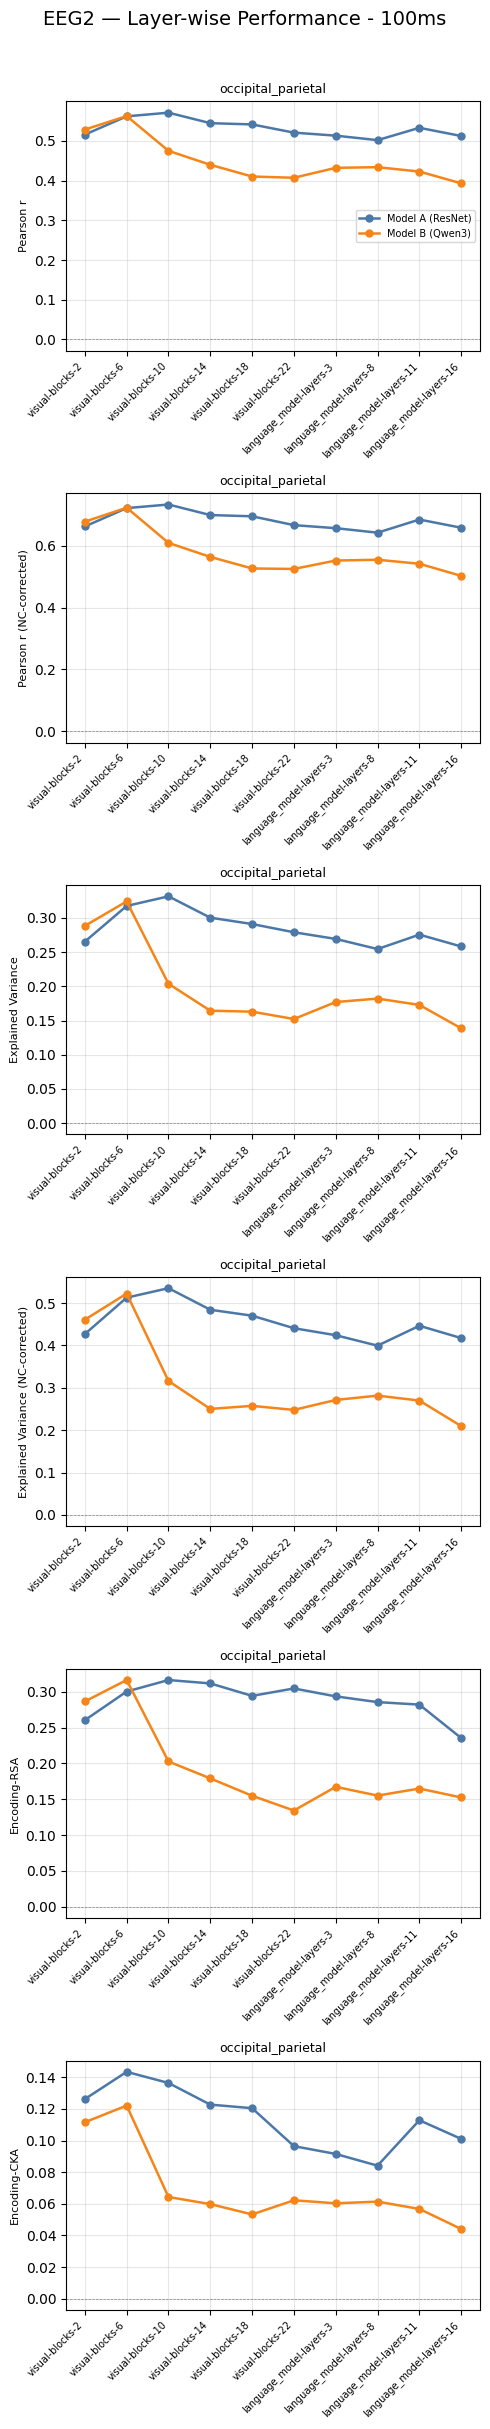

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance - 100ms", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = order_layers(tdf, model)
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


In [5]:
df_results = pd.read_csv("cuda_eeg_300ms_full.csv")
df_results.head()

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka
0,EEG2,Model A (ResNet),features/layer1-0,occipital_parietal,3.162278e+06,0.249843,0.377891,0.028428,0.055172,0.043294,0.012041
1,EEG2,Model A (ResNet),features/layer2-0,occipital_parietal,3.162278e+06,0.299507,0.454650,0.057120,0.123853,0.043906,0.018223
2,EEG2,Model A (ResNet),features/layer3-0,occipital_parietal,1.000000e+06,0.391938,0.597471,0.131641,0.299300,0.036209,0.028388
3,EEG2,Model A (ResNet),features/layer3-10,occipital_parietal,1.000000e+06,0.396290,0.605293,0.147094,0.339043,0.038536,0.031375
4,EEG2,Model A (ResNet),features/layer3-15,occipital_parietal,1.000000e+06,0.413959,0.632572,0.165989,0.383853,0.057098,0.037733


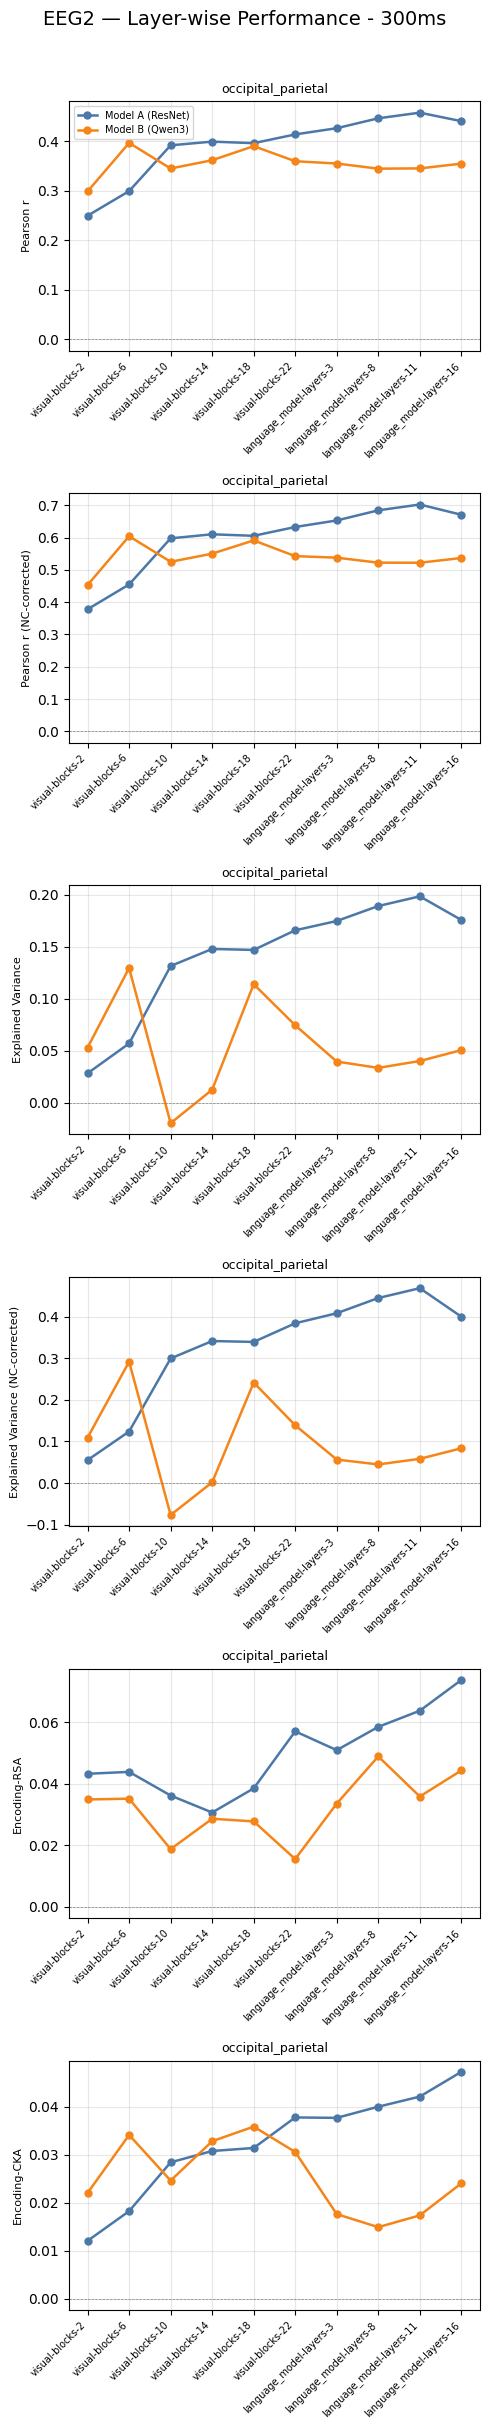

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance - 300ms", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = order_layers(tdf, model)
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


In [7]:
df_results = pd.read_csv("cuda_eeg_400ms_full.csv")
df_results.head()

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka
0,EEG2,Model A (ResNet),features/layer1-0,occipital_parietal,1000000.0,0.301174,0.453078,0.028457,0.047807,0.006883,0.021752
1,EEG2,Model A (ResNet),features/layer2-0,occipital_parietal,1000000.0,0.308581,0.460931,0.038400,0.061379,0.014554,0.034911
2,EEG2,Model A (ResNet),features/layer3-0,occipital_parietal,1000000.0,0.337632,0.503738,0.058412,0.102922,0.025841,0.042337
3,EEG2,Model A (ResNet),features/layer3-10,occipital_parietal,1000000.0,0.353055,0.527334,0.071840,0.135743,0.055061,0.053396
4,EEG2,Model A (ResNet),features/layer3-15,occipital_parietal,1000000.0,0.355898,0.529714,0.072241,0.135115,0.070439,0.061814


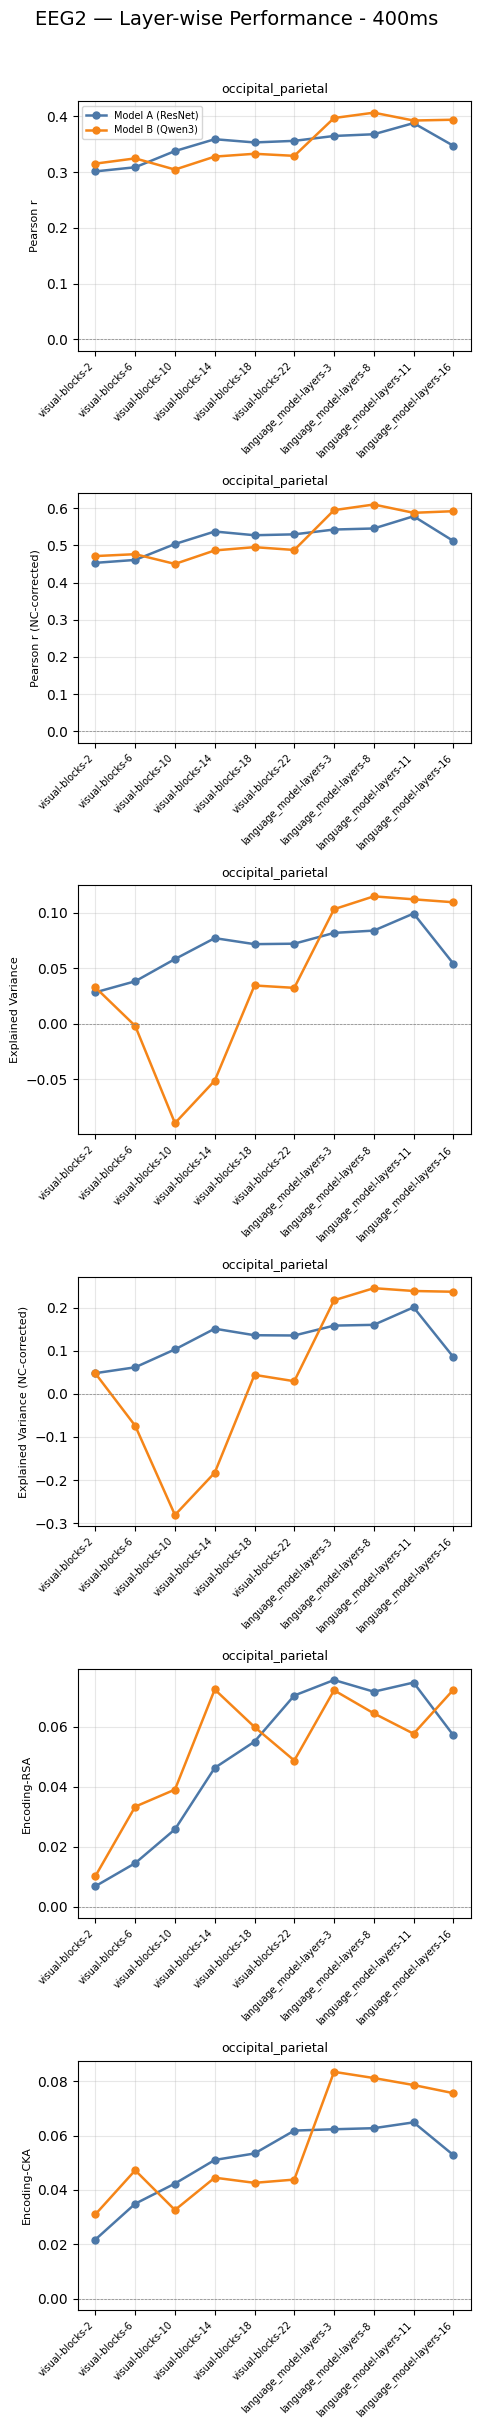

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance - 400ms", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = order_layers(tdf, model)
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()
